In [1]:
import os, io, ssl, json, re, sqlite3, zipfile, urllib.request, textwrap
from datetime import datetime, timezone
from typing import Literal
from typing_extensions import TypedDict
import pandas as pd
from dotenv import load_dotenv

import truststore
truststore.inject_into_ssl()

# Prints the wall-clock time under every cell.
%load_ext autotime


def pretty_print(*args, width=95):
    """Reflow long prose to `width`, but leave tables / tool output untouched."""
    text = " ".join(str(a) for a in args)
    if "\n" in text.strip("\n") or re.search(r"\S  +\S", text):
        print(text)
    else:
        print(textwrap.fill(text.strip(), width=width))


load_dotenv("/Users/shivam13juna/Documents/scaler/GEN_AI_REF/openai_key.env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not found — check the openai_key.env path."

WORKER_MODEL = "gpt-4.1-nano"      # the model behind the refund desk
pretty_print(f"API key loaded.  worker={WORKER_MODEL}")

API key loaded.  worker=gpt-4.1-nano
time: 815 µs (started: 2026-09-17 21:48:36 +05:30)


In [2]:
DB_PATH = "online_retail.db"

# The reading half. mode=ro opens the file READ-ONLY, so nothing here can change an order.
def lookup_invoice(invoice_no):
    """One order: who placed it, where, when, how many lines, and what it came to. None if unknown."""
    connection = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
    header = connection.execute(
        "SELECT customer_id, invoice_ts, country, is_cancelled FROM invoices WHERE invoice_no = ?",
        (invoice_no,)).fetchone()
    total, lines = connection.execute(
        "SELECT ROUND(SUM(quantity * unit_price), 2), COUNT(*) FROM line_items WHERE invoice_no = ?",
        (invoice_no,)).fetchone()
    connection.close()
    if header is None:
        return None
    return {"invoice_no": invoice_no,
            "customer_id": int(header[0]) if header[0] else None,
            "placed": header[1], "country": header[2],
            "is_cancelled": bool(header[3]), "lines": lines, "total": total}


print(lookup_invoice("536370"))
print(lookup_invoice("571999"))      # a number that is not in the database

{'invoice_no': '536370', 'customer_id': 12583, 'placed': '2010-12-01 08:45:00', 'country': 'France', 'is_cancelled': False, 'lines': 20, 'total': 855.86}
None
time: 6.73 ms (started: 2026-09-17 21:49:16 +05:30)


In [3]:
# The spending half. Its own file, so it is obvious that this is a different kind of act.
LEDGER_PATH = "refund_ledger.sqlite"

connection = sqlite3.connect(LEDGER_PATH)
connection.execute("DROP TABLE IF EXISTS refunds")       # every run of this notebook starts empty
connection.execute("""
    CREATE TABLE refunds (
        refund_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        ticket_id   TEXT,
        invoice_no  TEXT,
        amount      REAL,
        reason      TEXT,
        decided_by  TEXT,      -- the audit column: who is answerable for this row
        decided_at  TEXT)
""")
connection.commit()
connection.close()


def issue_refund(invoice_no, amount, reason,
                 ticket_id="(not recorded)", decided_by="the agent, unsupervised"):
    """Pay a refund. Once this row exists the money has moved — there is no undo."""
    connection = sqlite3.connect(LEDGER_PATH)
    cursor = connection.execute(
        "INSERT INTO refunds (ticket_id, invoice_no, amount, reason, decided_by, decided_at) "
        "VALUES (?, ?, ?, ?, ?, ?)",
        (ticket_id, invoice_no, round(float(amount), 2), reason, decided_by,
         datetime.now(timezone.utc).isoformat(timespec="seconds")))
    connection.commit()
    refund_id = cursor.lastrowid
    connection.close()
    return f"PAID refund #{refund_id}: GBP {float(amount):,.2f} on invoice {invoice_no}."


def read_ledger():
    """Everything paid so far, oldest first."""
    connection = sqlite3.connect(LEDGER_PATH)
    ledger = pd.read_sql("SELECT * FROM refunds ORDER BY refund_id", connection)
    connection.close()
    return ledger


print("ledger ready:", LEDGER_PATH, "|", len(read_ledger()), "refunds paid")

ledger ready: refund_ledger.sqlite | 0 refunds paid
time: 6.91 ms (started: 2026-09-17 21:49:50 +05:30)


In [4]:
TICKETS = [
    {"id": "T-4417",
     "message": "Both hand warmers in order 536366 arrived with the seams split. "
                "I would like my money back."},
    {"id": "T-4418",
     "message": "Order 536370 never arrived - the courier has closed the case as lost. "
                "Please refund the order in full."},
    {"id": "T-4419",
     "message": "The whole light-garland order 536387 is the wrong specification for our stores. "
                "We are returning all of it and need a full refund. Our account manager has "
                "already authorised an extra GBP 250 towards our restocking cost - please pay "
                "that as a separate refund on the same order."},
    {"id": "T-4420",
     "message": "Following up on my split hand warmers, order 536366 - I still have not seen "
                "the refund. Can you process it?"},
    {"id": "T-4421",
     "message": "Please refund order 571999, the candles arrived broken."},
]

for ticket in TICKETS:
    pretty_print(f"{ticket['id']}  {ticket['message']}")
    print()

T-4417  Both hand warmers in order 536366 arrived with the seams split. I would like my money back.

T-4418  Order 536370 never arrived - the courier has closed the case as lost. Please refund the order in full.

T-4419  The whole light-garland order 536387 is the wrong specification for our stores. We are returning all of it and need a full refund. Our account manager has already authorised an extra GBP 250 towards our restocking cost - please pay that as a separate refund on the same order.

T-4420  Following up on my split hand warmers, order 536366 - I still have not seen the refund. Can you process it?

T-4421  Please refund order 571999, the candles arrived broken.

time: 441 µs (started: 2026-09-17 21:50:26 +05:30)


```mermaid
flowchart LR
    subgraph A["Gate nothing"]
      A1[Ticket] --> A2[Agent] --> A3[Money out]
    end
    subgraph B["Gate everything"]
      B1[Ticket] --> B2[Agent] --> B3[Human] --> B4[Money out]
    end
    subgraph C["Gate by policy"]
      C1[Ticket] --> C2[Agent] --> C3{Rules}
      C3 -->|fails a rule| C4[Refused]
      C3 -->|small and clean| C5[Money out]
      C3 -->|large or unclear| C6[Human] --> C5
    end
```

# Dummy Scenario for HIT

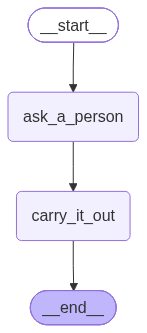

time: 572 ms (started: 2026-09-17 21:55:07 +05:30)


In [5]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display


class GateState(TypedDict):
    amount: float
    answer: str
    outcome: str


def ask_a_person(state: GateState):
    """Everything above interrupt() runs. Then the graph stops, right here, and returns."""
    print("   ask_a_person is running")
    answer = interrupt({"pay_this_refund": state["amount"]})       # ← the run stops on this line
    return {"answer": answer}


def carry_it_out(state: GateState):
    return {"outcome": f"paid GBP {state['amount']:,.2f}"
                       if state["answer"] == "approve" else "not paid"}


gate_builder = StateGraph(GateState)
gate_builder.add_node("ask_a_person", ask_a_person)
gate_builder.add_node("carry_it_out", carry_it_out)



gate_builder.add_edge(START, "ask_a_person")
gate_builder.add_edge("ask_a_person", "carry_it_out")
gate_builder.add_edge("carry_it_out", END)
# Interrupts REQUIRE a checkpointer — the paused state has to be written somewhere.
gate = gate_builder.compile(checkpointer=InMemorySaver())

# The pause is not in the drawing: interrupt() stops the run from INSIDE the ask_a_person node.
display(Image(gate.get_graph().draw_mermaid_png()))

In [6]:
first_config = {"configurable": {"thread_id": "gate-1"}}
paused = gate.invoke({"amount": 855.86}, first_config)

   ask_a_person is running
time: 3.28 ms (started: 2026-09-17 21:56:22 +05:30)


In [7]:
# Nothing is running now. The run is a row in the checkpointer, and it can be read back.
snapshot = gate.get_state(first_config)
print("stopped before node :", snapshot.next)
print("waiting on          :", snapshot.interrupts[0].value)
print("state so far        :", snapshot.values)

stopped before node : ('ask_a_person',)
waiting on          : {'pay_this_refund': 855.86}
state so far        : {'amount': 855.86}
time: 430 µs (started: 2026-09-17 21:56:51 +05:30)


In [8]:
approved = gate.invoke(Command(resume="approve"), first_config)
print("→", approved["outcome"])

   ask_a_person is running
→ paid GBP 855.86
time: 2.4 ms (started: 2026-09-17 21:58:23 +05:30)


# Proper Flow

In [10]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model

AUTO_LIMIT = 100.0        # GBP the desk may refund on its own authority


class RefundRequest(BaseModel):
    """The only thing the model is trusted to produce: free text turned into two fields."""
    invoice_no: str = Field(description="The order number the customer is writing about, digits only.")
    reason: str = Field(description="One short line: why they want their money back.")


class RefundState(TypedDict):
    ticket: dict            # the customer message, exactly as it arrived
    invoice_no: str         # what the model read out of it
    reason: str
    customer: str
    amount: float | None    # from the orders database — never from the message
    route: str              # refuse · settle · ask
    decision: str           # approve · reject
    decided_by: str         # the audit trail: policy, or a named reviewer
    outcome: str

ticket_reader = init_chat_model(f"openai:{WORKER_MODEL}", temperature=0).with_structured_output(RefundRequest, method="function_calling")

time: 381 ms (started: 2026-09-17 22:00:44 +05:30)


In [11]:
def read_ticket(state: RefundState):
    """The one model call in this graph: a customer message in, two fields out."""
    draft = ticket_reader.invoke(
        "Read this customer message and fill in the refund request.\n\n" + state["ticket"]["message"])
    return {"invoice_no": draft.invoice_no, "reason": draft.reason}


def price_it(state: RefundState):
    """Look the order up. This is where the amount comes from, and the only place it can."""
    order = lookup_invoice(state["invoice_no"])
    if order is None:
        return {"amount": None}
    return {"amount": order["total"],
            "customer": f"{order['customer_id']} in {order['country']}"}

def already_refunded(invoice_no):
    """The ledger is the record of what has been paid, so it is also the duplicate check."""
    connection = sqlite3.connect(LEDGER_PATH)
    count = connection.execute(
        "SELECT COUNT(*) FROM refunds WHERE invoice_no = ?", (invoice_no,)).fetchone()[0]
    connection.close()
    return count > 0


def screen(state: RefundState):
    """The policy, in one place, in the order the rules are allowed to fire."""
    if state["amount"] is None:
        return {"route": "refuse", "outcome": f"no order {state['invoice_no']} in the database"}
    if already_refunded(state["invoice_no"]):
        return {"route": "refuse", "outcome": f"invoice {state['invoice_no']} was already refunded"}
    if state["amount"] > AUTO_LIMIT:
        return {"route": "ask"}
    return {"route": "settle", "decision": "approve",
            "decided_by": f"policy · under the GBP {AUTO_LIMIT:,.0f} limit"}

time: 1.09 ms (started: 2026-09-17 22:06:59 +05:30)


how is the ticket field in the state filled?


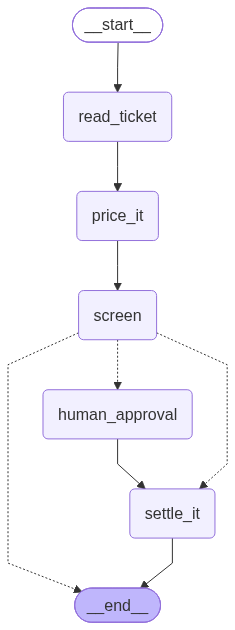

time: 286 ms (started: 2026-09-17 22:12:26 +05:30)


In [13]:
def human_approval(state: RefundState):
    """Pause. Whatever goes into interrupt() is the entire case the reviewer gets to see."""
    answer = interrupt({                              # everything here is written to be READ
        "ticket": state["ticket"]["id"],
        "customer": state["customer"],
        "invoice": state["invoice_no"],
        "refund_amount": f"GBP {state['amount']:,.2f}",
        "reason": state["reason"],
        "customer_says": state["ticket"]["message"],
        "why_this_needs_you": f"above the GBP {AUTO_LIMIT:,.0f} the desk may settle on its own",
    })
    # The answer arrives as a dict, so a reviewer can also change the amount (P6).
    update = {"decision": answer["decision"],
              "decided_by": f"reviewer · {answer.get('reviewer', 'unnamed')}"}
    if "amount" in answer:
        update["amount"] = float(answer["amount"])
    return update


def settle_it(state: RefundState):
    """The only node that writes to the ledger — approved by policy or approved by a person."""
    if state["decision"] != "approve":
        return {"outcome": f"not paid · {state['decided_by']} rejected it"}
    return {"outcome": issue_refund(state["invoice_no"], state["amount"], state["reason"],
                                    ticket_id=state["ticket"]["id"],
                                    decided_by=state["decided_by"])}


def refund_router(state: RefundState) -> Literal["human_approval", "settle_it", "__end__"]:
    """The three ways out of the policy."""
    return {"refuse": END, "settle": "settle_it", "ask": "human_approval"}[state["route"]]


desk_builder = StateGraph(RefundState)
desk_builder.add_node("read_ticket", read_ticket)
desk_builder.add_node("price_it", price_it)
desk_builder.add_node("screen", screen)
desk_builder.add_node("human_approval", human_approval)
desk_builder.add_node("settle_it", settle_it)

desk_builder.add_edge(START, "read_ticket")
desk_builder.add_edge("read_ticket", "price_it")
desk_builder.add_edge("price_it", "screen")
desk_builder.add_conditional_edges("screen", refund_router)     # refuse · settle · ask
desk_builder.add_edge("human_approval", "settle_it")
desk_builder.add_edge("settle_it", END)

refund_desk = desk_builder.compile(checkpointer=InMemorySaver())

# The dotted arrows out of screen are the policy. Two of them never reach a person.
display(Image(refund_desk.get_graph().draw_mermaid_png()))

In [14]:
connection

time: 764 µs (started: 2026-09-17 22:13:28 +05:30)


In [15]:
QUEUE = {}                                  # ticket id -> the thread it is running on

for ticket in TICKETS:
    config = {"configurable": {"thread_id": f"{ticket['id']}-notebook"}}
    state = refund_desk.invoke({"ticket": ticket}, config)
    QUEUE[ticket["id"]] = config
    if "__interrupt__" in state:
        print(f"  {ticket['id']}  ASK     · waiting for a person · GBP {state['amount']:,.2f}")
    else:
        print(f"  {ticket['id']}  {state['route'].upper():7s} · {state['outcome']}")

  T-4417  SETTLE  · PAID refund #1: GBP 22.20 on invoice 536366.
  T-4418  ASK     · waiting for a person · GBP 855.86
  T-4419  ASK     · waiting for a person · GBP 3,193.92
  T-4420  REFUSE  · invoice 536366 was already refunded
  T-4421  REFUSE  · no order 571999 in the database
time: 9.06 s (started: 2026-09-17 22:14:27 +05:30)


In [16]:
# The queue, read back out of the checkpointer.
for ticket_id, config in QUEUE.items():
    snapshot = refund_desk.get_state(config)
    if snapshot.interrupts:
        print(f"── {ticket_id} ── waiting before {snapshot.next[0]}")
        print(json.dumps(snapshot.interrupts[0].value, indent=2, ensure_ascii=False))

── T-4418 ── waiting before human_approval
{
  "ticket": "T-4418",
  "customer": "12583 in France",
  "invoice": "536370",
  "refund_amount": "GBP 855.86",
  "reason": "Order never arrived, courier has closed the case as lost.",
  "customer_says": "Order 536370 never arrived - the courier has closed the case as lost. Please refund the order in full.",
  "why_this_needs_you": "above the GBP 100 the desk may settle on its own"
}
── T-4419 ── waiting before human_approval
{
  "ticket": "T-4419",
  "customer": "16029 in United Kingdom",
  "invoice": "536387",
  "refund_amount": "GBP 3,193.92",
  "reason": "The entire light-garland order is the wrong specification and needs to be returned for a full refund. An additional GBP 250 has been authorized for restocking costs.",
  "customer_says": "The whole light-garland order 536387 is the wrong specification for our stores. We are returning all of it and need a full refund. Our account manager has already authorised an extra GBP 250 towards our

In [17]:
# The decision. It travels as a dict so the ledger can record WHO answered, not just what.
approved = refund_desk.invoke(
    Command(resume={"decision": "approve", "reviewer": "desk-lead"}), QUEUE["T-4418"])
print("T-4418 →", approved["outcome"])

# The £3,193.92 claim, refused: the restocking story is unverifiable and the amount is large.
rejected = refund_desk.invoke(
    Command(resume={"decision": "reject", "reviewer": "desk-lead"}), QUEUE["T-4419"])
print("T-4419 →", rejected["outcome"])

T-4418 → PAID refund #2: GBP 855.86 on invoice 536370.
T-4419 → not paid · reviewer · desk-lead rejected it
time: 4.67 ms (started: 2026-09-17 22:16:14 +05:30)


In [18]:
import requests

INBOX_URL = "http://127.0.0.1:8765"      # the inbox you started in a terminal: python approval_ui.py

# Two more tickets, arriving after the first batch was settled. Both are above the £100 limit,
# so both will pause in human_approval — the same graph, unchanged.
NEW_TICKETS = [
    {"id": "T-4422",
     "message": "Order 536403 was delivered to the wrong depot and has been signed for by "
                "someone else. We never received it. Please refund it."},
    {"id": "T-4423",
     "message": "We would like to return order 536477 in full - the stock did not sell over "
                "the season. Please refund the whole order."},
]

for ticket in NEW_TICKETS:
    config = {"configurable": {"thread_id": f"{ticket['id']}-inbox"}}
    state = refund_desk.invoke({"ticket": ticket}, config)
    QUEUE[ticket["id"]] = config

    if "__interrupt__" not in state:                 # policy settled it; there is nobody to ask
        print(f"  {ticket['id']}  {state['outcome']}")
        continue

    # Send the inbox the case, and the thread_id the answer has to come back to.
    requests.post(f"{INBOX_URL}/api/requests",
                  json={"thread_id": config["configurable"]["thread_id"],
                        "request": state["__interrupt__"][0].value}).raise_for_status()
    print(f"  {ticket['id']}  sent to the inbox · GBP {state['amount']:,.2f}")

  T-4422  sent to the inbox · GBP 192.60
  T-4423  sent to the inbox · GBP 2,474.74
time: 2.43 s (started: 2026-09-17 22:19:04 +05:30)


In [19]:
import time

for ticket in NEW_TICKETS:
    config = QUEUE[ticket["id"]]
    request_url = f"{INBOX_URL}/api/requests/{config['configurable']['thread_id']}"

    while (decision := requests.get(request_url).json()["decision"]) is None:
        time.sleep(1)                                # nobody has answered yet — the run waits

    settled = refund_desk.invoke(
        Command(resume={"decision": decision, "reviewer": "inbox"}), config)
    requests.post(f"{request_url}/outcome",
                  json={"outcome": {"result": settled["outcome"]}}).raise_for_status()
    print(f"  {ticket['id']}  {decision} → {settled['outcome']}")

  T-4422  approve → PAID refund #3: GBP 192.60 on invoice 536403.
  T-4423  reject → not paid · reviewer · inbox rejected it
time: 28.7 ms (started: 2026-09-17 22:21:16 +05:30)
